<a href="https://colab.research.google.com/github/hclperera/Cat-Breed-Identification/blob/main/Implementation2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
from google.colab import drive
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Extract dataset from ZIP
drive_path = '/content/drive/MyDrive/Project/cats2.zip'
extract_path = '/content/dataset'

if os.path.exists(drive_path):
    with zipfile.ZipFile(drive_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully to /content/dataset")
else:
    print("Error: ZIP file not found in Drive. Check the file name.")

Dataset extracted successfully to /content/dataset


In [3]:
BATCH_SIZE = 32
IMG_SIZE = (180, 180)
data_dir = '/content/dataset/cat breeds'

print("Loading and Splitting Dataset...")

# 1. Load Training Dataset (80% of data)
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# 2. Load the Initial Validation Dataset (The remaining 20%)
initial_val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Target Breeds: {class_names}")

# 3. Split the 20% evenly into 10% Validation and 10% Testing
val_batches = tf.data.experimental.cardinality(initial_val_ds)
test_ds = initial_val_ds.take(val_batches // 2)
val_ds = initial_val_ds.skip(val_batches // 2)

print(f"Training batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Validation batches: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Testing batches: {tf.data.experimental.cardinality(test_ds).numpy()}")

Loading and Splitting Dataset...
Found 4000 files belonging to 4 classes.
Using 3200 files for training.
Found 4000 files belonging to 4 classes.
Using 800 files for validation.
Target Breeds: ['Bombay', 'Calico', 'Persian', 'Siamese']
Training batches: 100
Validation batches: 13
Testing batches: 12


In [ ]:
model_v2 = models.Sequential([
    # Input Rescaling to normalize pixel values [0, 1]
    layers.Rescaling(1./255, input_shape=(180, 180, 3)),

    # Convolutional Layers for Feature Extraction
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Fully Connected Layers for Classification
    layers.Flatten(),
    layers.Dense(128, activation='relu'),

    # IMPROVEMENT: Adding Dropout (50%) to reduce overfitting
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(num_classes)
])

# Compile the model
model_v2.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model_v2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,929,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,023,748 (30.61 MB)

 Trainable params: 8,023,748 (30.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 10

# Training the model
print("Starting Training for Model v2...")
history_v2 = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Starting Training for Model v2...
Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - accuracy: 0.3851 - loss: 1.4557 - val_accuracy: 0.5745 - val_loss: 0.9657
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 63ms/step - accuracy: 0.5642 - loss: 1.0011 - val_accuracy: 0.6058 - val_loss: 0.8568
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.6363 - loss: 0.8551 - val_accuracy: 0.6250 - val_loss: 0.8584
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.6955 - loss: 0.7335 - val_accuracy: 0.6394 - val_loss: 0.8893
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.7818 - loss: 0.5802 - val_accuracy: 0.6490 - val_loss: 0.9125
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.8183 - loss: 0.4757 - val_accuracy: 0.6442 - val_loss: 0.9933
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.8559 - loss: 0.3914 - val_accuracy: 0.6466 - val_loss: 1.0897
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - accu

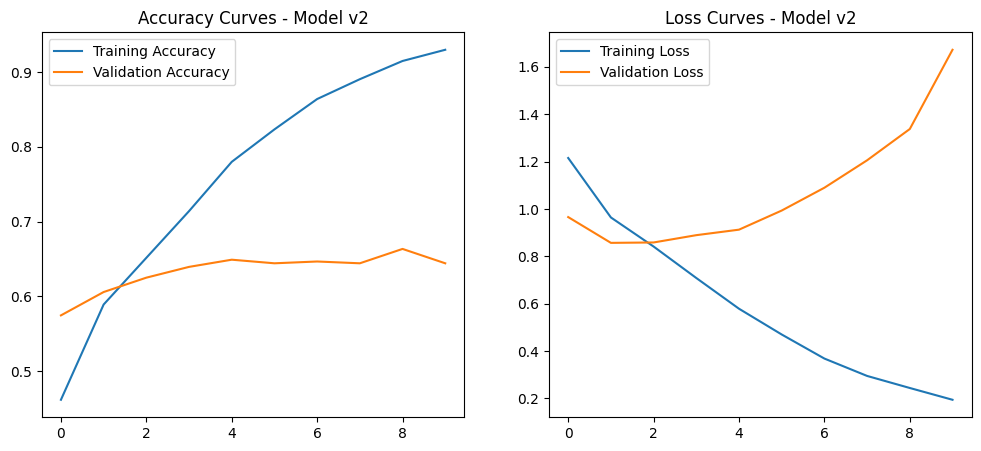

In [ ]:
# Visualizing Performance
acc = history_v2.history['accuracy']
val_acc = history_v2.history['val_accuracy']
loss = history_v2.history['loss']
val_loss = history_v2.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Accuracy Curves - Model v2')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Loss Curves - Model v2')
plt.legend()
plt.show()

In [ ]:
# Save the final model (Updated to model_v2.h5 as per guidelines)
model_save_path = '/content/drive/MyDrive/Project/model_v2.h5'
model_v2.save(model_save_path)
print(f"Model saved successfully to: {model_save_path}")

Model saved successfully to: /content/drive/MyDrive/Project/model_v2.h5


Evaluating model_v2 on the Unseen Test Dataset...

CLASSIFICATION REPORT - MODEL v2 (CLEAN DATA + DROPOUT)
              precision    recall  f1-score   support

      Bombay       0.65      0.90      0.76        92
      Calico       0.61      0.72      0.66        96
     Persian       0.80      0.52      0.63       102
     Siamese       0.64      0.53      0.58        94

    accuracy                           0.66       384
   macro avg       0.68      0.67      0.66       384
weighted avg       0.68      0.66      0.66       384



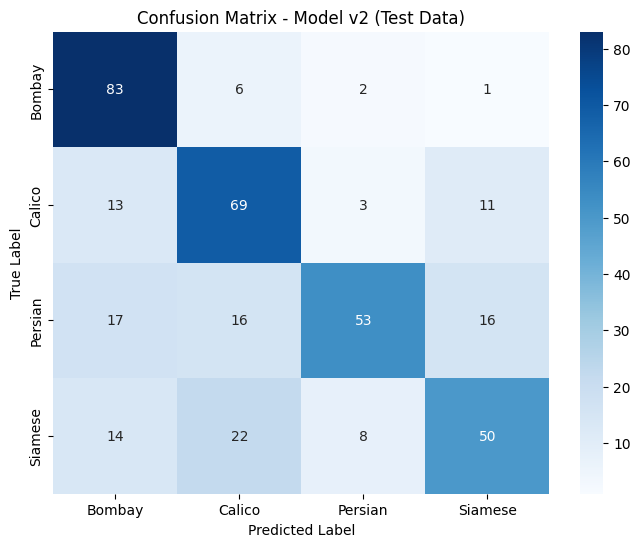

In [ ]:
print("Evaluating model_v2 on the Unseen Test Dataset...")
y_true = []
y_pred = []

# Extracting true labels and making predictions
for images, labels in test_ds:
    y_true.extend(labels.numpy())
    preds = model_v2.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))


# 1. Print the Classification Report

print("\n" + "="*60)
print("CLASSIFICATION REPORT - MODEL v2 (CLEAN DATA + DROPOUT)")
print("="*60)
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# 2. Plot the Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Model v2 (Test Data)')
plt.show()

In [ ]:
# Manual Test
print("Upload a cat image to test:")
uploaded = files.upload()

for fn in uploaded.keys():
    img = image.load_img(fn, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) # Create a batch

    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    plt.imshow(img)
    plt.title(f"Predicted: {class_names[np.argmax(score)]} ({100 * np.max(score):.2f}%)")
    plt.axis('off')
    plt.show()

Model V3

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal", input_shape=(180, 180, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Define Model v3
model_v3 = models.Sequential([
    # 1. Augmentation Layer
    data_augmentation,

    # 2. Rescaling
    layers.Rescaling(1./255),

    # 3. Convolutional Blocks
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # 4. Fully Connected Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),

    # Dropout for Regularization
    layers.Dropout(0.5),

    layers.Dense(num_classes)
])

model_v3.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model_v3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,929,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,023,748 (30.61 MB)

 Trainable params: 8,023,748 (30.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Training the Model v3

epochs = 20 #increased number of epochs to 20

print("Starting Training for Model v3 (With Augmentation)...")
history_v3 = model_v3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Starting Training for Model v3 (With Augmentation)...
Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.3460 - loss: 1.3574 - val_accuracy: 0.4952 - val_loss: 1.0727
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.4938 - loss: 1.1118 - val_accuracy: 0.5577 - val_loss: 0.9957
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - accuracy: 0.5460 - loss: 1.0269 - val_accuracy: 0.5793 - val_loss: 0.9689
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.5836 - loss: 0.9759 - val_accuracy: 0.6034 - val_loss: 0.9284
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.6103 - loss: 0.9255 - val_accuracy: 0.6034 - val_loss: 0.8916
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.6103 - loss: 0.9122 - val_accuracy: 0.6370 - val_loss: 0.8313
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.6219 - loss: 0.8965 - val_accuracy: 0.6178 - val_loss: 0.8890
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1

In [ ]:
#saving the model_v3
model_save_path = '/content/drive/MyDrive/Project/model_v3.h5'
model_v3.save(model_save_path)
print(f"Model v3 saved successfully to: {model_save_path}")

Model v3 saved successfully to: /content/drive/MyDrive/Project/model_v3.h5


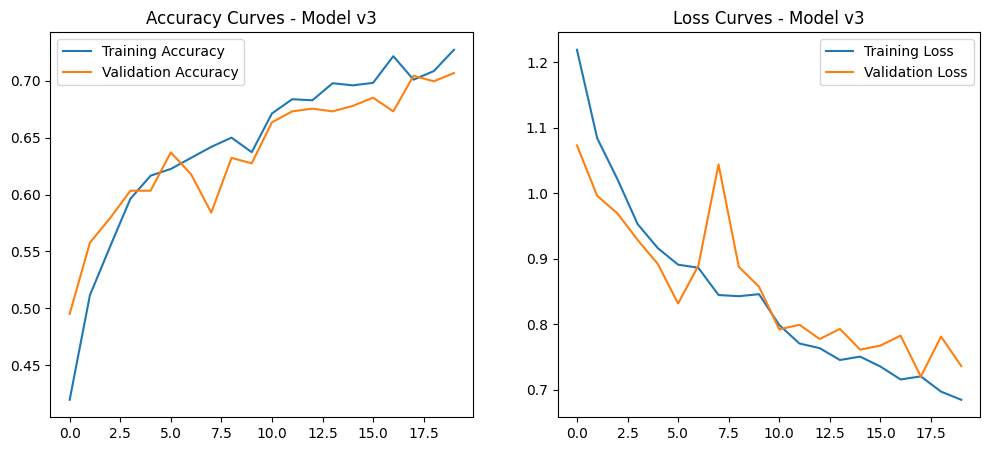

In [ ]:
acc = history_v3.history['accuracy']
val_acc = history_v3.history['val_accuracy']
loss = history_v3.history['loss']
val_loss = history_v3.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Accuracy Curves - Model v3')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Loss Curves - Model v3')
plt.legend()
plt.show()

Evaluating model_v3 on the Unseen Test Dataset...

CLASSIFICATION REPORT - MODEL v3 (AUGMENTATION + DROPOUT)
              precision    recall  f1-score   support

      Bombay       0.79      0.95      0.86       100
      Calico       0.67      0.71      0.69        97
     Persian       0.73      0.56      0.63        97
     Siamese       0.71      0.69      0.70        90

    accuracy                           0.73       384
   macro avg       0.73      0.73      0.72       384
weighted avg       0.73      0.73      0.72       384



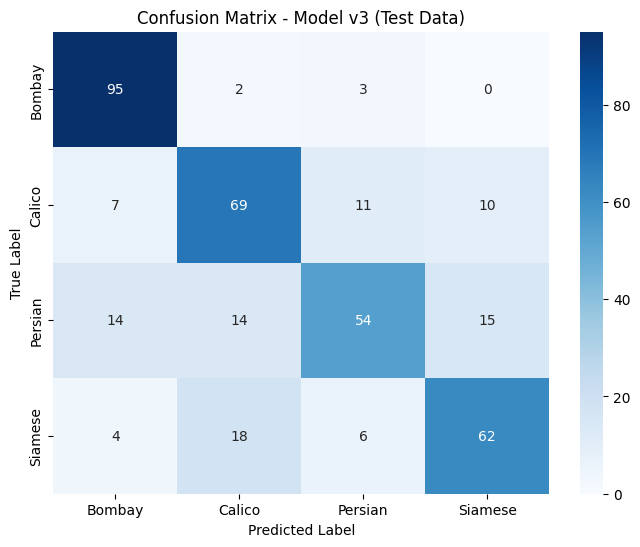

In [ ]:
print("Evaluating model_v3 on the Unseen Test Dataset...")
y_true = []
y_pred = []

# Extracting true labels and making predictions
for images, labels in test_ds:
    y_true.extend(labels.numpy())
    preds = model_v3.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))

# 1. Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT - MODEL v3 (AUGMENTATION + DROPOUT)")
print("="*60)
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# 2. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Model v3 (Test Data)')
plt.show()

Model v4

In [ ]:
print("Building Model v4 Architecture...")

# 1. Augmentation Layer to generalize the model
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal", input_shape=(180, 180, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# 2. Model v4 Architecture
model_v4 = models.Sequential([
    # Data Augmentation and Rescaling
    data_augmentation,
    layers.Rescaling(1./255),

    # Convolutional Layers for Feature Extraction
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Fully Connected Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),

    # Dropout to prevent overfitting
    layers.Dropout(0.5),

    layers.Dense(num_classes)
])

model_v4.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model_v4.summary()

Building Model v4 Architecture...


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     7,929,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,023,748 (30.61 MB)

 Trainable params: 8,023,748 (30.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Stop training if validation loss does not improve for 5 epochs
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True # Always keep the best performing weights
)

epochs = 50 # Increased it again since early stopping will halt it at the optimal point
print("Starting Training for Model v4 (With Early Stopping)...")

history_v4 = model_v4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stopping]
)

Starting Training for Model v4 (With Early Stopping)...
Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.3518 - loss: 1.4154 - val_accuracy: 0.5072 - val_loss: 1.0528
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.5057 - loss: 1.0791 - val_accuracy: 0.5433 - val_loss: 1.0154
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.5441 - loss: 1.0318 - val_accuracy: 0.5889 - val_loss: 0.9599
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.5965 - loss: 0.9550 - val_accuracy: 0.5769 - val_loss: 0.9125
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.5902 - loss: 0.9247 - val_accuracy: 0.6202 - val_loss: 0.8861
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.6264 - loss: 0.8841 - val_accuracy: 0.6274 - val_loss: 0.8482
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.6213 - loss: 0.8780 - val_accuracy: 0.6250 - val_loss: 0.8599
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 

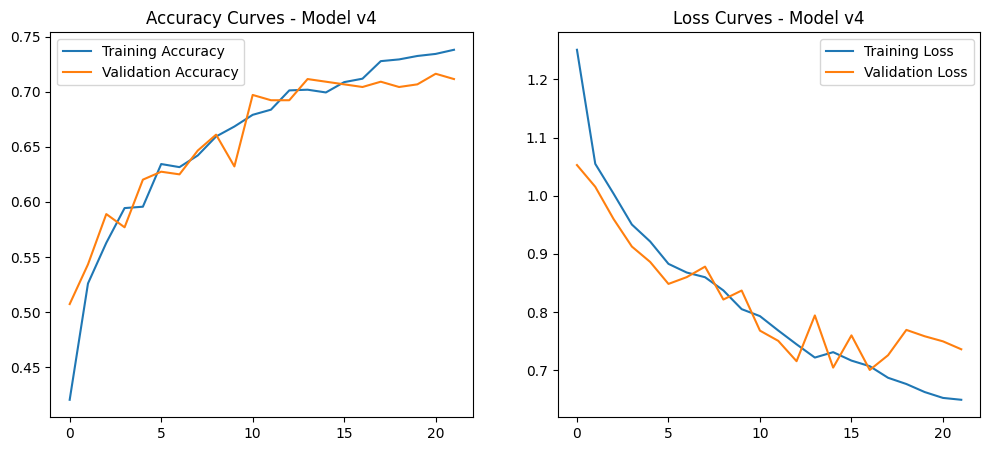

In [ ]:
acc = history_v4.history['accuracy']
val_acc = history_v4.history['val_accuracy']
loss = history_v4.history['loss']
val_loss = history_v4.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Accuracy Curves - Model v4')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Loss Curves - Model v4')
plt.legend()
plt.show()


Evaluating Model v4 on the Unseen Test Dataset...

CLASSIFICATION REPORT - MODEL v4 (EARLY STOPPING)
              precision    recall  f1-score   support

      Bombay       0.80      0.86      0.83        96
      Calico       0.66      0.72      0.69        90
     Persian       0.74      0.55      0.63        99
     Siamese       0.61      0.67      0.64        99

    accuracy                           0.70       384
   macro avg       0.70      0.70      0.70       384
weighted avg       0.70      0.70      0.69       384



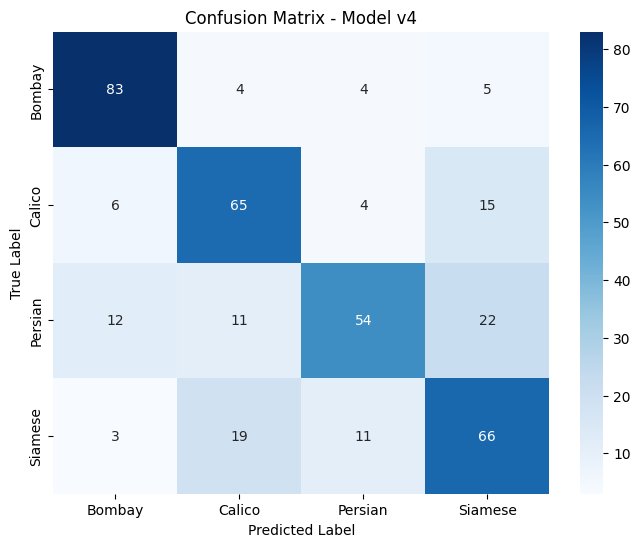

In [ ]:
print("\nEvaluating Model v4 on the Unseen Test Dataset...")
y_true = []
y_pred = []

# Extracting true labels and making predictions
for images, labels in test_ds:
    y_true.extend(labels.numpy())
    preds = model_v4.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))

# 1. Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT - MODEL v4 (EARLY STOPPING)")
print("="*60)
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# 2. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Model v4')
plt.show()

In [ ]:
model_save_path = '/content/drive/MyDrive/Project/model_v4.h5'
model_v4.save(model_save_path)
print(f"Model v4 saved successfully to: {model_save_path}")

Model v4 saved successfully to: /content/drive/MyDrive/Project/model_v4.h5


Model v5


In [4]:
# Load Pre-trained MobileNetV2 Model (excluding the top classification layers)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(180, 180, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the base model to preserve pre-trained features
base_model.trainable = False
print("Base model loaded and frozen successfully.")

/tmp/ipykernel_2126/1838687560.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Base model loaded and frozen successfully.


In [5]:
print("Building Model v5 Architecture...")

# 1. Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# 2. MobileNetV2 Preprocessing Layer (Required for MobileNet)
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

# 3. Create Final Model Architecture
model_v5 = tf.keras.Sequential([
    layers.Input(shape=(180, 180, 3)),
    data_augmentation,
    layers.Lambda(preprocess_input),

    base_model, # The frozen MobileNetV2 base

    # Custom layers for our 4 cat breeds
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(num_classes)
])

model_v5.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model_v5.summary()

Building Model v5 Architecture...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
early_stopping_v5 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("\nStarting Training for Model v5 (Transfer Learning)...")
epochs = 50

history_v5 = model_v5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stopping_v5]
)


Starting Training for Model v5 (Transfer Learning)...
Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - accuracy: 0.6036 - loss: 1.0510 - val_accuracy: 0.9375 - val_loss: 0.1869
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.8990 - loss: 0.2840 - val_accuracy: 0.9423 - val_loss: 0.1449
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - accuracy: 0.9167 - loss: 0.2407 - val_accuracy: 0.9567 - val_loss: 0.1353
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.9206 - loss: 0.2230 - val_accuracy: 0.9447 - val_loss: 0.1461
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.9287 - loss: 0.2187 - val_accuracy: 0.9471 - val_loss: 0.1326
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.9345 - loss: 0.1918 - val_accuracy: 0.9543 - val_loss: 0.0962
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.9398 - loss: 0.1659 - val_accuracy: 0.9663 - val_loss: 0.1164
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━

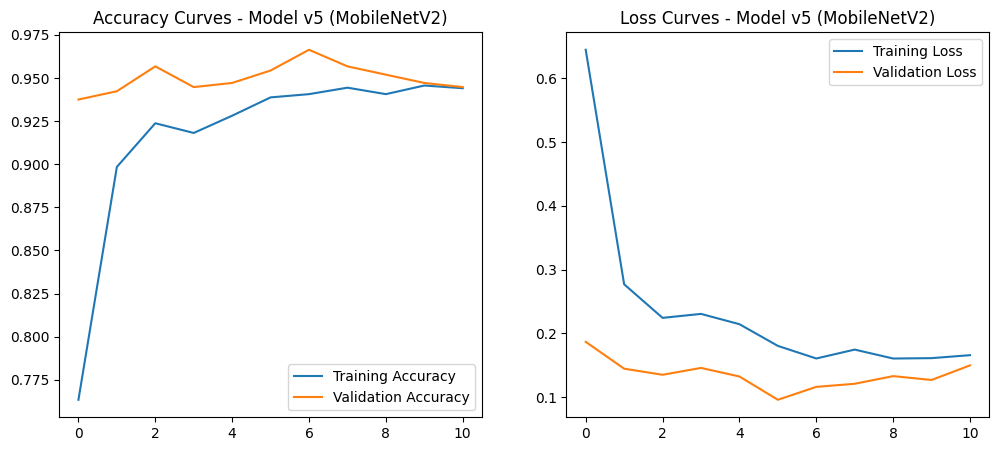

In [ ]:
acc = history_v5.history['accuracy']
val_acc = history_v5.history['val_accuracy']
loss = history_v5.history['loss']
val_loss = history_v5.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Accuracy Curves - Model v5 (MobileNetV2)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Loss Curves - Model v5 (MobileNetV2)')
plt.legend()
plt.show()


Evaluating Model v5 on UNSEEN Test Dataset...

CLASSIFICATION REPORT - MODEL v5 (MOBILENETV2)
              precision    recall  f1-score   support

      Bombay       0.95      0.99      0.97        92
      Calico       0.98      0.95      0.96        95
     Persian       0.97      0.94      0.95        97
     Siamese       0.95      0.97      0.96       100

    accuracy                           0.96       384
   macro avg       0.96      0.96      0.96       384
weighted avg       0.96      0.96      0.96       384



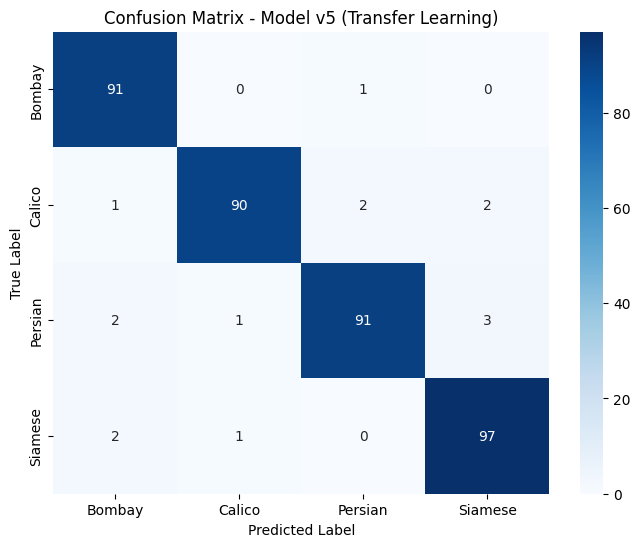

In [ ]:
print("\nEvaluating Model v5 on UNSEEN Test Dataset...")
y_true = []
y_pred = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())
    preds = model_v5.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))

# Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT - MODEL v5 (MOBILENETV2)")
print("="*60)
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Model v5 (Transfer Learning)')
plt.show()

In [ ]:
model_save_path = '/content/drive/MyDrive/Project/model_v5.h5'
model_v5.save(model_save_path)
print(f"Model v5 saved successfully to: {model_save_path}")

Model v5 saved successfully to: /content/drive/MyDrive/Project/model_v5.h5


In [6]:
# Load the saved weights to avoid retraining!
model_v5.load_weights('/content/drive/MyDrive/Project/model_v5.h5')
print("Saved Model Loaded Successfully!")

Saved Model Loaded Successfully!


Generating Sample Predictions...


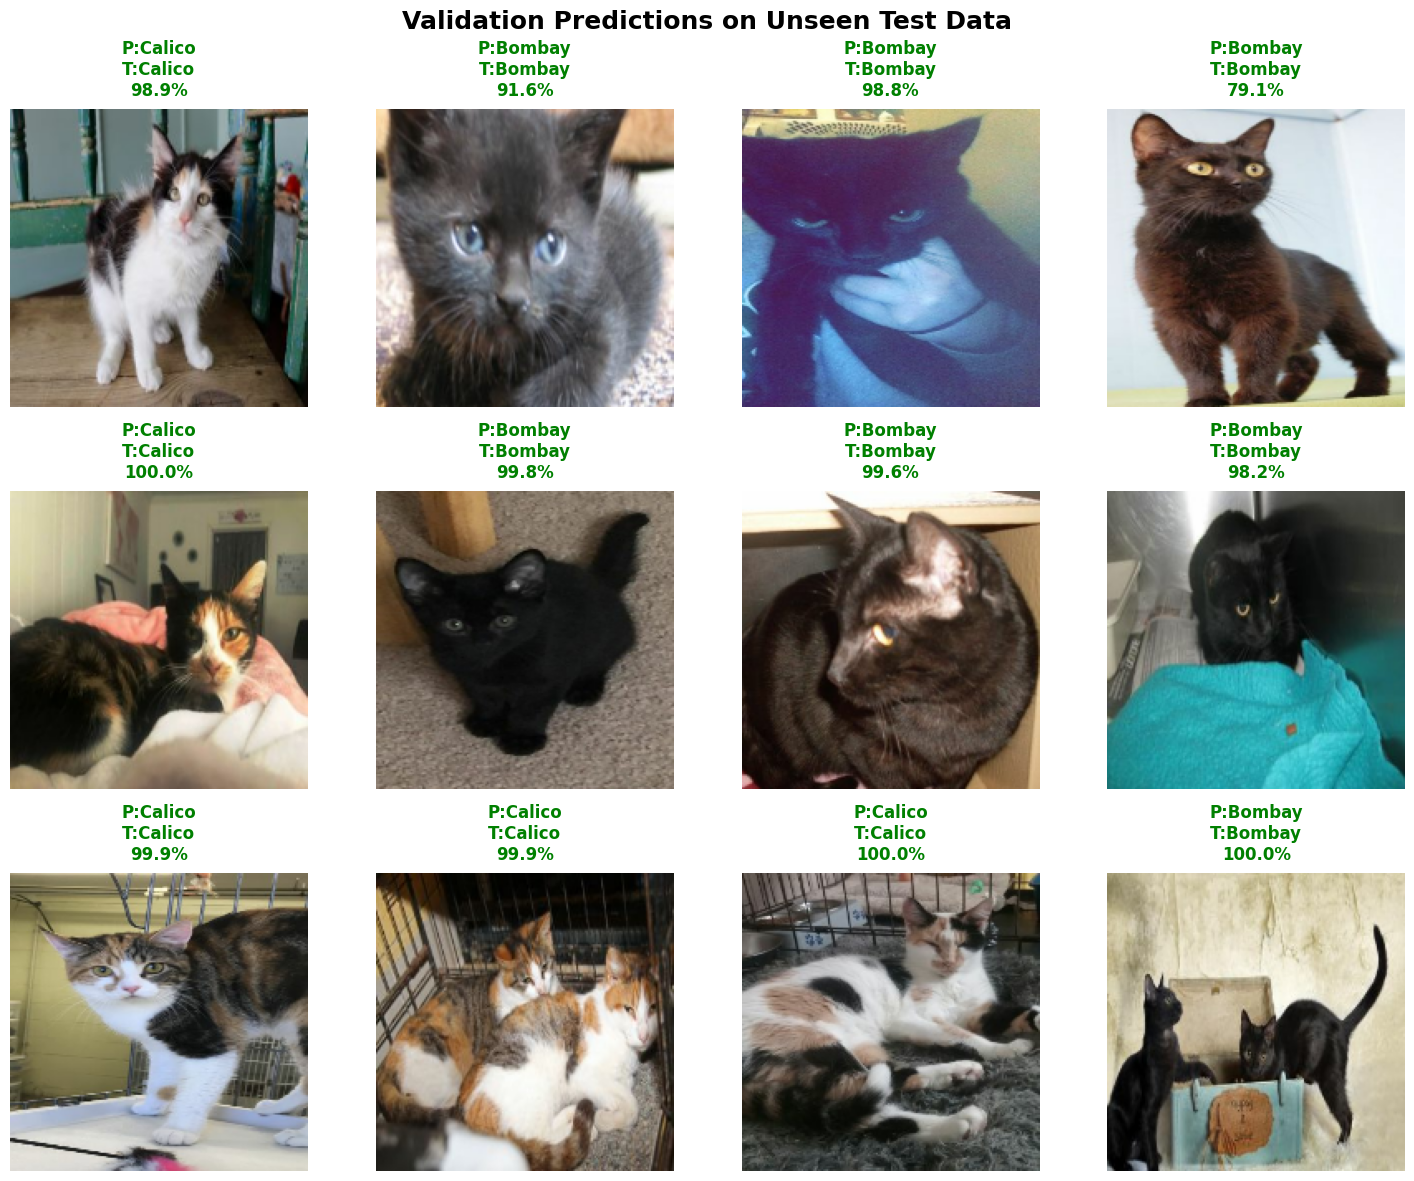

In [7]:
print("Generating Sample Predictions...")

# 1. Get a single batch of images and labels from the Test Dataset
for images, labels in test_ds.take(1):
    sample_images = images.numpy()
    sample_labels = labels.numpy()
    break

# 2. Make predictions using the final model (model_v5)
predictions = model_v5.predict(sample_images, verbose=0)

# Apply softmax to convert logits to probabilities (since from_logits=True)
probabilities = tf.nn.softmax(predictions).numpy()

# 3. Plot the 3x4 grid
plt.figure(figsize=(15, 12))
plt.subplots_adjust(hspace=0.5)

for i in range(12): # We will show 12 images
    plt.subplot(3, 4, i + 1)

    # Get True Label
    true_idx = sample_labels[i]
    true_class = class_names[true_idx]

    # Get Predicted Label and Confidence
    pred_idx = np.argmax(probabilities[i])
    pred_class = class_names[pred_idx]
    confidence = probabilities[i][pred_idx] * 100

    # Check if prediction is correct to set text color
    color = 'green' if true_idx == pred_idx else 'red'

    # Display the image (Convert to uint8 for matplotlib)
    plt.imshow(sample_images[i].astype("uint8"))

    # Format the title text exactly like the example
    title_text = f"P:{pred_class}\nT:{true_class}\n{confidence:.1f}%"
    plt.title(title_text, color=color, fontsize=12, pad=10, fontweight='bold')
    plt.axis('off')

plt.suptitle("Validation Predictions on Unseen Test Data", fontsize=18, y=0.98, fontweight='bold')
plt.tight_layout()
plt.show()